# Sistema de Recomendación — Last.fm


## 1. Setup
### 1.1 Instalación de PySpark

In [5]:
# Instalación de PySpark en Colab
!pip install pyspark --quiet

### 1.2 Carga de datos
#Descarga automática de Last.fm 360K desde Internet Archive
(la fuente de GitHub está caída, el mirror de IA es confiable)

In [6]:
import os, tarfile

!wget -q --show-progress \
    "https://archive.org/download/lastfm-dataset-360K/lastfm-dataset-360K.tar.gz" \
    -O /tmp/lastfm-360K.tar.gz

with tarfile.open("/tmp/lastfm-360K.tar.gz", "r:gz") as tar:
    tar.extractall("/tmp/")

for f in os.listdir("/tmp/lastfm-dataset-360K/"):
    print(f"{f}: {os.path.getsize(f'/tmp/lastfm-dataset-360K/{f}'):,} bytes")

/tmp/lastfm-360K.ta 100%[===================>] 542.83M  37.7MB/s    in 14s     


/tmp/ipykernel_58/2829443789.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/tmp/")


README.txt: 2,071 bytes
usersha1-profile.tsv: 24,644,914 bytes
usersha1-artmbid-artname-plays.tsv: 1,642,981,585 bytes
mbox_sha1sum.py: 199 bytes


### 1.3 Imports y configuración de SparkSession

Configuramos Spark para el entorno de Colab (single node, ~12GB RAM):
- `driver.memory 4g`: reservamos 4GB para el driver donde corre ALS
- `shuffle.partitions 200`: adecuado para ~5M filas en un solo nodo
- `autoBroadcastJoinThreshold -1`: desactivamos broadcast joins para evitar OOM en joins de features

In [8]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, FloatType
from pyspark.ml.feature import StringIndexer
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

spark = SparkSession.builder \
    .appName("LastFM_ALS") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.sql.autoBroadcastJoinThreshold", "-1") \
    .config("spark.sql.broadcastTimeout", "300") \
    .getOrCreate()

print("Spark version:", spark.version)
print("driver.memory:", spark.conf.get("spark.driver.memory"))
print("shuffle.partitions:", spark.conf.get("spark.sql.shuffle.partitions"))

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/18 23:41:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.2
driver.memory: 4g
shuffle.partitions: 200


### 1.4 Carga de datos

In [10]:
BASE_PATH = "/tmp/lastfm-dataset-360K/"

# plays: sin header, separador \t, 4 columnas
# Usamos try_cast para manejar valores nulos en plays sin romper el pipeline
plays_df = spark.read.text(BASE_PATH + "usersha1-artmbid-artname-plays.tsv") \
    .select(F.split(F.col("value"), "\t").alias("f")) \
    .select(
        F.col("f")[0].alias("userID"),
        F.col("f")[1].alias("artistID"),   # MBID del artista
        F.col("f")[2].alias("artist_name"),
        F.expr("try_cast(f[3] as int)").alias("weight")
    ) \
    .filter(F.col("weight").isNotNull())  # eliminar filas corruptas

# profile: género, edad, país — features adicionales de usuario
profile_df = spark.read.text(BASE_PATH + "usersha1-profile.tsv") \
    .select(F.split(F.col("value"), "\t").alias("f")) \
    .select(
        F.col("f")[0].alias("userID"),
        F.col("f")[1].alias("gender"),
        F.expr("try_cast(f[2] as int)").alias("age"),
        F.col("f")[3].alias("country")
    )

# interactions_raw mantiene el nombre que usa el resto del notebook (que habíamos hecho con el dataset original HetRec)
interactions_raw = plays_df.cache()

print(f"Interacciones crudas: {interactions_raw.count():,}")
print(f"Usuarios en profile:  {profile_df.count():,}")
interactions_raw.printSchema()
interactions_raw.show(5, truncate=False)

Interacciones crudas: 17,559,530
Usuarios en profile:  359,347
root
 |-- userID: string (nullable = true)
 |-- artistID: string (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- weight: integer (nullable = true)

+----------------------------------------+------------------------------------+--------------------+------+
|userID                                  |artistID                            |artist_name         |weight|
+----------------------------------------+------------------------------------+--------------------+------+
|00000c289a1829a808ac09c00daf10bc3c4e223b|3bd73256-3905-4f3a-97e2-8b341527f805|betty blowtorch     |2137  |
|00000c289a1829a808ac09c00daf10bc3c4e223b|f2fb0ff0-5679-42ec-a55c-15109ce6e320|die Ärzte           |1099  |
|00000c289a1829a808ac09c00daf10bc3c4e223b|b3ae82c2-e60b-4551-a76d-6620f1b456aa|melissa etheridge   |897   |
|00000c289a1829a808ac09c00daf10bc3c4e223b|3d6bbeb7-f90e-4d10-b440-e153c0d10b53|elvenking           |717   |
|00000c289a1829

## 2. Exploración y análisis con PySpark

In [11]:
# Estadísticas básicas del dataset crudo
n_users = interactions_raw.select("userID").distinct().count()
n_artists = interactions_raw.select("artistID").distinct().count()
n_interactions = interactions_raw.count()

# Densidad: proporción de celdas no vacías en la matriz usuario-artista
# Una densidad baja indica una matriz muy sparse, típica en recomendación
density = n_interactions / (n_users * n_artists)

print(f"Usuarios únicos:       {n_users:,}")
print(f"Artistas únicos:       {n_artists:,}")
print(f"Interacciones totales: {n_interactions:,}")
print(f"Densidad de la matriz: {density:.6f} ({density*100:.4f}%)")
print()
print("Estadísticas de play counts (weight):")
interactions_raw.select("weight").summary("min", "25%", "50%", "75%", "max", "mean").show()

Usuarios únicos:       359,349
Artistas únicos:       160,168
Interacciones totales: 17,559,530
Densidad de la matriz: 0.000305 (0.0305%)

Estadísticas de play counts (weight):


+-------+------------------+
|summary|            weight|
+-------+------------------+
|    min|                 0|
|    25%|                35|
|    50%|                94|
|    75%|               224|
|    max|            419157|
|   mean|215.18530888924704|
+-------+------------------+



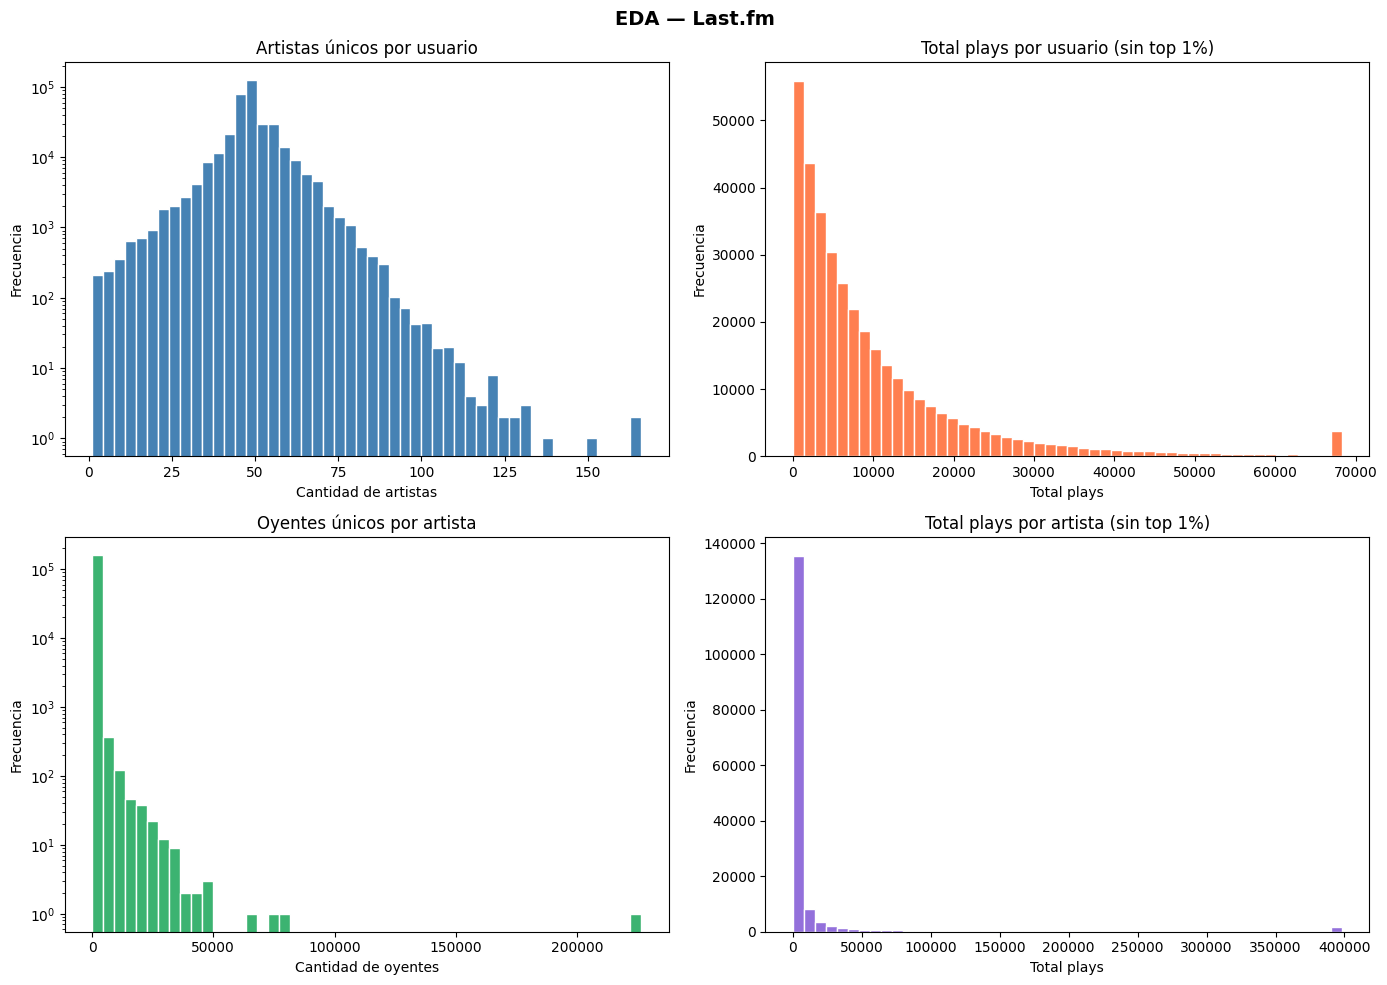

Observación: el top 1% de artistas (1601) concentra el 64.1% de todas las escuchas.


In [12]:
# Distribuciones por usuario y por artista
# Todo el cálculo ocurre en Spark; toPandas() solo para el plot final

plays_per_user = interactions_raw \
    .groupBy("userID") \
    .agg(
        F.count("artistID").alias("n_artists"),
        F.sum("weight").alias("total_plays")
    )

plays_per_artist = interactions_raw \
    .groupBy("artistID") \
    .agg(
        F.count("userID").alias("n_listeners"),
        F.sum("weight").alias("total_plays")
    )

# toPandas() justificado solo para objetos agregados: una fila por usuario/artista, no las 17.5M interacciones
# En producción/100M interacciones se graficaría sobre agregados muestreados o persistidos en Parquet/Delta
df_user = plays_per_user.toPandas()
df_artist = plays_per_artist.toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA — Last.fm", fontsize=14, fontweight="bold")

# Plot 1: distribución de artistas únicos por usuario
axes[0, 0].hist(df_user["n_artists"], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Artistas únicos por usuario")
axes[0, 0].set_xlabel("Cantidad de artistas")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].set_yscale("log")

# Plot 2: total plays por usuario (cortamos el top 1% para visualizar mejor)
p99_user = df_user["total_plays"].quantile(0.99)
axes[0, 1].hist(df_user["total_plays"].clip(upper=p99_user), bins=50, color="coral", edgecolor="white")
axes[0, 1].set_title("Total plays por usuario (sin top 1%)")
axes[0, 1].set_xlabel("Total plays")
axes[0, 1].set_ylabel("Frecuencia")

# Plot 3: oyentes únicos por artista
axes[1, 0].hist(df_artist["n_listeners"], bins=50, color="mediumseagreen", edgecolor="white")
axes[1, 0].set_title("Oyentes únicos por artista")
axes[1, 0].set_xlabel("Cantidad de oyentes")
axes[1, 0].set_ylabel("Frecuencia")
axes[1, 0].set_yscale("log")

# Plot 4: total plays por artista (long tail)
p99_art = df_artist["total_plays"].quantile(0.99)
axes[1, 1].hist(df_artist["total_plays"].clip(upper=p99_art), bins=50, color="mediumpurple", edgecolor="white")
axes[1, 1].set_title("Total plays por artista (sin top 1%)")
axes[1, 1].set_xlabel("Total plays")
axes[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Observación: concentración de escuchas en el top de artistas
# Esto es evidencia de una distribución power-law: pocos artistas muy populares y una larga cola de nicho
# ALS con implicitPrefs=True es más adecuado que trabajar con ratings crudos
top_1pct_n = max(1, int(len(df_artist) * 0.01))
top_1pct_plays = df_artist.nlargest(top_1pct_n, "total_plays")["total_plays"].sum()
total_plays = df_artist["total_plays"].sum()
print(f"Observación: el top 1% de artistas ({top_1pct_n}) "
      f"concentra el {top_1pct_plays/total_plays*100:.1f}% de todas las escuchas.")

## 3. Preprocesamiento con PySpark

In [13]:
# 4.1 Filtrado del subconjunto
# Criterio: usuarios con entre 10 y 500 escuchas TOTALES
# (suma de plays, no cantidad de artistas únicos)
# Esto filtra usuarios con actividad mínima y power users atípicos
# La elección se justifica porque conserva usuarios con señal suficiente y reduce shuffles/memoria.

user_stats = interactions_raw \
    .groupBy("userID") \
    .agg(
        F.sum("weight").alias("total_plays"),
        F.countDistinct("artistID").alias("n_artists")
    )

valid_users = user_stats.filter(
    (F.col("total_plays") >= 10) & (F.col("total_plays") <= 500)
).select("userID")

# Artistas con al menos 50 oyentes únicos --> elimina long tail extremo
valid_artists = interactions_raw \
    .groupBy("artistID") \
    .agg(F.countDistinct("userID").alias("n_listeners")) \
    .filter(F.col("n_listeners") >= 50) \
    .select("artistID")

interactions = interactions_raw \
    .join(valid_users, on="userID", how="inner") \
    .join(valid_artists, on="artistID", how="inner")

n_sub = interactions.count()
n_u = interactions.select("userID").distinct().count()
n_a = interactions.select("artistID").distinct().count()
density_sub = n_sub / (n_u * n_a)

print(f"Subconjunto: {n_u:,} usuarios | {n_a:,} artistas | {n_sub:,} interacciones")
print(f"Densidad del subconjunto: {density_sub:.4f} ({density_sub*100:.2f}%)")
print(f"Reducción respecto al dataset completo: {n_sub/17_559_530*100:.1f}%")
print(f"Retención de usuarios: {n_u:,}/359,349 ({n_u/359_349*100:.1f}%)")

Subconjunto: 22,125 usuarios | 25,128 artistas | 809,540 interacciones
Densidad del subconjunto: 0.0015 (0.15%)
Reducción respecto al dataset completo: 4.6%
Retención de usuarios: 22,125/359,349 (6.2%)


In [46]:
# Contar usuarios y artistas ORIGINALES
n_users_original = interactions_raw.select("userID").distinct().count()
n_artists_original = interactions_raw.select("artistID").distinct().count()
n_interactions_original = interactions_raw.count()

# Retención porcentual
retention_users_pct = (n_u / n_users_original) * 100
retention_artists_pct = (n_a / n_artists_original) * 100
retention_interactions_pct = (n_sub / n_interactions_original) * 100

# Densidad
density_original = n_interactions_original / (n_users_original * n_artists_original)
density_sub = n_sub / (n_u * n_a)

# Reporte
print("ESTADÍSTICAS DE FILTRADO Y SUBCONJUNTO")
print()
print("DATASET ORIGINAL (completo):")
print(f"  Usuarios:      {n_users_original:,}")
print(f"  Artistas:      {n_artists_original:,}")
print(f"  Interacciones: {n_interactions_original:,}")
print(f"  Densidad:      {density_original:.4f} ({density_original*100:.4f}%)")
print()
print("SUBCONJUNTO FILTRADO (10–500 plays/usuario, ≥50 oyentes/artista):")
print(f"  Usuarios:      {n_u:,} ({retention_users_pct:.1f}% del original)")
print(f"  Artistas:      {n_a:,} ({retention_artists_pct:.1f}% del original)")
print(f"  Interacciones: {n_sub:,} ({retention_interactions_pct:.1f}% del original)")
print(f"  Densidad:      {density_sub:.4f} ({density_sub*100:.2f}%)")
print()
print("OBSERVACIONES:")
print(f"  • Densidad aumentó {density_sub/density_original:.1f}× (filtrado más concentrado)")
print(f"  • Usuarios retenidos: {retention_users_pct:.1f}% (se excluyen: sin historial + power users)")
print(f"  • Artistas retenidos: {retention_artists_pct:.1f}% (se excluyen: tail muy largo)")
print(f"  • Interacciones manejables: {n_sub:,} << {n_interactions_original:,}")

ESTADÍSTICAS DE FILTRADO Y SUBCONJUNTO

DATASET ORIGINAL (completo):
  Usuarios:      359,349
  Artistas:      160,168
  Interacciones: 17,559,530
  Densidad:      0.0003 (0.0305%)

SUBCONJUNTO FILTRADO (10–500 plays/usuario, ≥50 oyentes/artista):
  Usuarios:      22,125 (6.2% del original)
  Artistas:      25,128 (15.7% del original)
  Interacciones: 809,540 (4.6% del original)
  Densidad:      0.0015 (0.15%)

OBSERVACIONES:
  • Densidad aumentó 4.8× (filtrado más concentrado)
  • Usuarios retenidos: 6.2% (se excluyen: sin historial + power users)
  • Artistas retenidos: 15.7% (se excluyen: tail muy largo)
  • Interacciones manejables: 809,540 << 17,559,530


### 4.1.1 Sesgos introducidos por el subconjunto

El filtro de usuarios con entre 10 y 500 plays y artistas con al menos 50 oyentes hace que el experimento sea viable en Colab, pero introduce sesgos que deben explicitarse:

- **Sesgo de popularidad:** se eliminan artistas de long tail, por lo que el catálogo evaluado queda más concentrado en artistas conocidos.
- **Menor diversidad:** el modelo aprende mejor patrones sobre artistas populares que sobre nichos musicales.
- **Usuarios extremos fuera:** se excluyen usuarios con actividad muy alta, que podrían tener gustos más ricos, y usuarios con señal casi nula.
- **Métricas interpretables con alcance limitado:** Precision@K, Recall@K y NDCG@K son confiables para evaluar recomendación dentro del subconjunto filtrado, pero no miden bien descubrimiento de artistas raros o nuevos.

Esta decisión es razonable para una prueba de concepto en infraestructura gratuita, pero en producción se debería complementar con métricas de cobertura, diversidad y long-tail recommendation.


In [14]:
# 4.2 Features adicionales de usuario y artista
# ALS no permite usar features adicionales, pero igualmente se plantean features posibles

# Features de usuario 1 y 2: calculadas desde las interacciones
user_features = interactions \
    .groupBy("userID") \
    .agg(
        F.log1p(F.sum("weight")).alias("log_total_plays"),
        F.countDistinct("artistID").alias("n_unique_artists")
    )

# Features de usuario 3 y 4: género y país desde profile_df
# Estas features demográficas no estaban disponibles en el dataset 2k
# y permiten incorporar contexto del usuario más allá del comportamiento
profile_features = profile_df.select("userID", "gender", "country") \
    .fillna("unknown", subset=["gender", "country"])

# Join: combinamos features de comportamiento + demográficas
user_features = user_features \
    .join(profile_features, on="userID", how="left") \
    .fillna("unknown", subset=["gender", "country"])

# Features de artista 1 y 2: popularidad y alcance
# Nota: el dataset 360K no tiene archivo de tags — eliminamos n_distinct_tags
artist_features = interactions \
    .groupBy("artistID") \
    .agg(
        F.log1p(F.sum("weight")).alias("log_artist_popularity"),
        F.countDistinct("userID").alias("n_unique_listeners")
    )

print("Features de usuario:")
user_features.show(5)
print("Features de artista:")
artist_features.show(5)

Features de usuario:


+--------------------+------------------+----------------+------+-------------+
|              userID|   log_total_plays|n_unique_artists|gender|      country|
+--------------------+------------------+----------------+------+-------------+
|08d151ec9db6a2445...|   5.6937321388027|              43|     f|United States|
|75c9aa9461e6ce5cf...| 5.241747015059643|              41|     m|      Germany|
|8ee3a1db574dc11de...| 4.418840607796598|              42|     m|       Turkey|
|a5277a1fb76d24af1...|6.1675164908883415|              43|     f|      Germany|
|afc860ec400e2204f...| 4.787491742782046|              28|     f|    Lithuania|
+--------------------+------------------+----------------+------+-------------+
only showing top 5 rows
Features de artista:


+--------------------+---------------------+------------------+
|            artistID|log_artist_popularity|n_unique_listeners|
+--------------------+---------------------+------------------+
|0004537a-4b12-43e...|     5.19295685089021|                46|
|0008af7d-2aa1-4b4...|   1.6094379124341003|                 1|
|000b1990-4dd8-483...|    4.624972813284271|                23|
|000fecd9-ae03-49b...|    4.553876891600541|                22|
|0012ecdb-5c15-498...|   2.3978952727983707|                 4|
+--------------------+---------------------+------------------+
only showing top 5 rows


In [15]:
# 4.3 Re-indexación con StringIndexer
# ALS requiere índices enteros contiguos desde 0
# StringIndexer los genera automáticamente a partir de los IDs originales
# Importante: fiteamos sobre el subconjunto ya filtrado, no sobre el dataset completo

user_indexer = StringIndexer(inputCol="userID", outputCol="user_index")
artist_indexer = StringIndexer(inputCol="artistID", outputCol="artist_index")

user_indexer_model = user_indexer.fit(interactions)
artist_indexer_model = artist_indexer.fit(interactions)

interactions_indexed = user_indexer_model.transform(interactions)
interactions_indexed = artist_indexer_model.transform(interactions_indexed)

# Unimos features al dataset indexado
interactions_indexed = interactions_indexed \
    .join(user_features, on="userID", how="left") \
    .join(artist_features, on="artistID", how="left")

# Casteamos tipos: ALS requiere Integer para índices y Float para ratings
interactions_indexed = interactions_indexed \
    .withColumn("user_index", F.col("user_index").cast(IntegerType())) \
    .withColumn("artist_index", F.col("artist_index").cast(IntegerType())) \
    .withColumn("rating", F.col("weight").cast(FloatType()))

interactions_indexed.printSchema()
interactions_indexed.show(5)

root
 |-- artistID: string (nullable = true)
 |-- userID: string (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- weight: integer (nullable = true)
 |-- user_index: integer (nullable = true)
 |-- artist_index: integer (nullable = true)
 |-- log_total_plays: double (nullable = true)
 |-- n_unique_artists: long (nullable = true)
 |-- gender: string (nullable = true)
 |-- country: string (nullable = true)
 |-- log_artist_popularity: double (nullable = true)
 |-- n_unique_listeners: long (nullable = true)
 |-- rating: float (nullable = true)



26/06/18 23:52:53 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/06/18 23:53:35 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/06/18 23:53:36 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/18 23:53:36 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB


+--------------------+--------------------+--------------------+------+----------+------------+-----------------+----------------+------+------------------+---------------------+------------------+------+
|            artistID|              userID|         artist_name|weight|user_index|artist_index|  log_total_plays|n_unique_artists|gender|           country|log_artist_popularity|n_unique_listeners|rating|
+--------------------+--------------------+--------------------+------+----------+------------+-----------------+----------------+------+------------------+---------------------+------------------+------+
|0002f649-8285-4a7...|9baec07305eb5b7df...|   sparks the rescue|    27|     18502|       21781|5.929589143389895|              24|     m|     United States|   3.4657359027997265|                 2|  27.0|
|0001cd84-2a11-469...|666f797c8b3165733...|              midway|     1|     15925|       10514|4.634728988229636|              31|     m|         Australia|   4.1588830833596715|  

In [16]:
# 4.4 Persistencia en Parquet
# Guardamos el dataset procesado para evitar recomputar el pipeline en caso
# de necesitar relanzar celdas posteriores dentro de la misma sesión

PARQUET_PATH = "/content/lastfm_processed"

interactions_indexed.write \
    .mode("overwrite") \
    .parquet(PARQUET_PATH)

print("Dataset procesado guardado en:", PARQUET_PATH)

# Para recargar sin recomputar:
# interactions_indexed = spark.read.parquet(PARQUET_PATH)

26/06/18 23:55:49 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/06/18 23:56:17 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/06/18 23:56:20 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB


Dataset procesado guardado en: /content/lastfm_processed


In [17]:
# 4.5 Train / Test split por usuario
# En recomendadores es preferible separar train/test por usuario, no con randomSplit global.
# Objetivo: que cada usuario evaluado conserve historial en train y tenga al menos un artista en test.
# Como Last.fm 360K no trae timestamp en este archivo, usamos una partición aleatoria reproducible por usuario.

USER_SPLIT_SEED = 42

w_user = Window.partitionBy("user_index").orderBy(F.rand(seed=USER_SPLIT_SEED))
w_count = Window.partitionBy("user_index")

split_df = interactions_indexed     .withColumn("rn_user", F.row_number().over(w_user))     .withColumn("n_user_interactions", F.count("*").over(w_count))

# Dejamos 1 interacción por usuario para test solo cuando el usuario tiene al menos 2 interacciones.
# El resto queda en train. Esto evita usuarios de test sin historial de entrenamiento.
test_df = split_df.filter(
    (F.col("n_user_interactions") >= 2) & (F.col("rn_user") == 1)
).drop("rn_user", "n_user_interactions")

train_df = split_df.filter(
    (F.col("n_user_interactions") == 1) | (F.col("rn_user") > 1)
).drop("rn_user", "n_user_interactions")

train_df.cache()
test_df.cache()

print(f"Train: {train_df.count():,} interacciones")
print(f"Test:  {test_df.count():,} interacciones")
print(f"Usuarios con test: {test_df.select('user_index').distinct().count():,}")

26/06/18 23:59:04 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/06/18 23:59:09 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/06/18 23:59:11 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/18 23:59:16 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/06/18 23:59:26 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB


Train: 787,440 interacciones


26/06/19 00:01:26 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/06/19 00:01:55 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/06/19 00:01:58 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:02:01 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/06/19 00:02:08 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/06/19 00:02:12 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB


Test:  22,100 interacciones


Usuarios con test: 22,100


## 4.6 Benchmark de tiempos del pipeline de Spark

Medimos el tiempo de las etapas principales para documentar el costo computacional de cada paso. Esta informacion guia las decisiones de optimizacion descritas en la seccion de escalabilidad.

Benchmark de tiempos (datos en cache):

  Recarga desde Parquet                        0.51s


  Filtrado del subconjunto (users + artistas)  46.04s


  Feature engineering (groupBy + agg)         44.99s


  StringIndexer (fit + transform)             88.24s


26/06/19 00:05:17 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/06/19 00:05:17 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:05:17 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:05:24 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:05:31 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:05:33 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:05:38 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:05:39 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:05:39 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:05:40 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:05:41 WARN DAGScheduler: 

  ALS fit (rank=10, regParam=0.1, maxIter=10)  43.28s

                      Etapa  Tiempo (s)
      Recarga desde Parquet        0.51
   Filtrado del subconjunto       46.04
        Feature engineering       44.99
StringIndexer fit+transform       88.24
       ALS fit (maxIter=10)       43.28


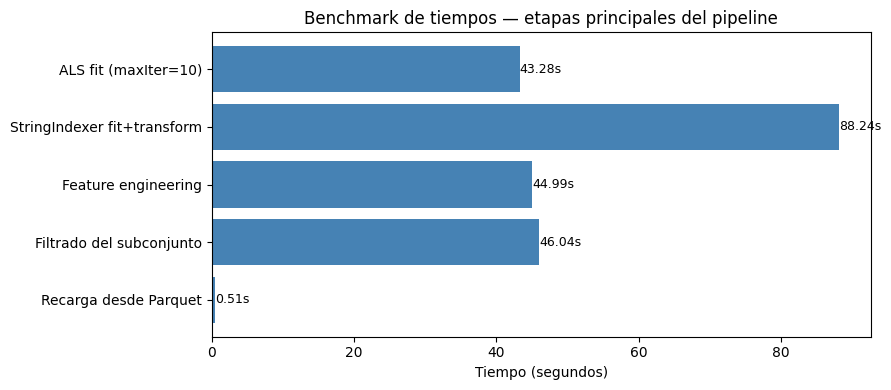


Nota: en un cluster Databricks con 4 workers las etapas de filtrado
y feature engineering escalarian linealmente con los cores disponibles.
ALS con implicitPrefs escala horizontalmente dividiendo la matriz en bloques.


In [18]:
# 4.6 Benchmark de tiempos del pipeline
# es más rápido que la realidad, pero sirve como para ver que procesos tardan más
import time

def timed(label, fn):
    t0 = time.time()
    result = fn()
    elapsed = round(time.time() - t0, 2)
    print(f'  {label:<42s} {elapsed:6.2f}s')
    return elapsed

print('Benchmark de tiempos (datos en cache):\n')
bench = {}

bench['Recarga desde Parquet'] = timed(
    'Recarga desde Parquet',
    lambda: spark.read.parquet(PARQUET_PATH).count()
)

bench['Filtrado del subconjunto'] = timed(
    'Filtrado del subconjunto (users + artistas)',
    lambda: interactions_raw
        .join(valid_users, on='userID', how='inner')
        .join(valid_artists, on='artistID', how='inner')
        .count()
)

bench['Feature engineering'] = timed(
    'Feature engineering (groupBy + agg)',
    lambda: interactions.groupBy('userID')
        .agg(F.log1p(F.sum('weight')).alias('lp'), F.countDistinct('artistID').alias('nu'))
        .count()
)

bench['StringIndexer fit+transform'] = timed(
    'StringIndexer (fit + transform)',
    lambda: StringIndexer(inputCol='userID', outputCol='ui')
        .fit(interactions).transform(interactions).count()
)

bench['ALS fit (maxIter=10)'] = timed(
    'ALS fit (rank=10, regParam=0.1, maxIter=10)',
    lambda: ALS(
        maxIter=10, rank=10, regParam=0.1,
        userCol='user_index', itemCol='artist_index',
        ratingCol='rating', coldStartStrategy='drop', implicitPrefs=True
    ).fit(train_df)
)


# Tabla y grafico de barras
bench_df = pd.DataFrame(list(bench.items()), columns=['Etapa', 'Tiempo (s)'])
print()
print(bench_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(bench_df['Etapa'], bench_df['Tiempo (s)'], color='steelblue')
ax.set_xlabel('Tiempo (segundos)')
ax.set_title('Benchmark de tiempos — etapas principales del pipeline')
for bar, v in zip(bars, bench_df['Tiempo (s)']):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}s', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nNota: en un cluster Databricks con 4 workers las etapas de filtrado')
print('y feature engineering escalarian linealmente con los cores disponibles.')
print('ALS con implicitPrefs escala horizontalmente dividiendo la matriz en bloques.')


## 5. Modelo: ALS

Usamos ALS con `implicitPrefs=True` porque Last.fm tiene interacciones implícitas (play counts), no ratings explícitos. En modo implícito, ALS interpreta el `rating` como una señal de confianza/preferencia observada.

El mejor modelo se selecciona por métricas de ranking —especialmente NDCG@10— y no por RMSE. RMSE se reporta solo como referencia secundaria, porque con `implicitPrefs=True` la predicción no debe interpretarse como play count real.


In [19]:
# 5.1 Funciones de evaluación ranking-aware
# Punto crítico: se excluyen de las recomendaciones los artistas ya vistos en train.
# Así evaluamos capacidad de recomendar nuevos artistas relevantes, no de repetir historial.
#
# Implementación con funciones de arrays nativas de Spark (array_intersect, array_except, etc.)
# en vez de UDFs de Python: evita el ida y vuelta JVM<->Python por cada fila, que es lo que
# vuelve lentas a las UDFs cuando se llaman muchas veces (acá las métricas corren 14 veces
# entre el grid de hiperparámetros y la curva de entrenamiento).

K = 10
K_CANDIDATES = 100

def build_als_eval_df(model, k=K, k_candidates=K_CANDIDATES):
    # Genera eval_df con recomendaciones filtradas: no incluye artistas vistos en train.
    recs_raw = model.recommendForAllUsers(k_candidates).select(
        "user_index",
        F.col("recommendations.artist_index").alias("rec_artists_raw")
    )
    train_seen = train_df.groupBy("user_index").agg(F.collect_set("artist_index").alias("train_artists"))
    ground_truth = test_df.groupBy("user_index").agg(F.collect_set("artist_index").alias("actual_artists"))

    # array_except saca los vistos en train manteniendo el orden por score; slice recorta a k
    eval_df = (
        recs_raw
        .join(train_seen, on="user_index", how="inner")
        .join(ground_truth, on="user_index", how="inner")
        .withColumn("rec_artists", F.slice(F.array_except("rec_artists_raw", "train_artists"), 1, k))
        .select("user_index", "rec_artists", "actual_artists", "train_artists")
    )
    return eval_df

def evaluate_ranking(eval_df, k=K):
    # Métricas calculadas con expresiones de arrays nativas (sin UDFs).
    # hits = cantidad de recomendados que están en el ground truth.
    metrics_df = (
        eval_df
        .withColumn("n_rec", F.size("rec_artists"))
        .withColumn("n_actual", F.size("actual_artists"))
        .withColumn("n_hits", F.size(F.array_intersect("rec_artists", "actual_artists")))
        .withColumn("precision", F.col("n_hits") / F.lit(float(k)))
        .withColumn(
            "recall",
            F.when(F.col("n_actual") > 0, F.col("n_hits") / F.col("n_actual")).otherwise(F.lit(0.0))
        )
        # Para NDCG necesitamos las posiciones de los hits dentro de rec_artists.
        # transform recorre el array con índice: si el artista está en actual, aporta 1/log2(pos+2).
        .withColumn(
            "dcg",
            F.aggregate(
                F.transform(
                    "rec_artists",
                    lambda aid, i: F.when(
                        F.array_contains(F.col("actual_artists"), aid),
                        1.0 / F.log2(i.cast("double") + 2.0)
                    ).otherwise(F.lit(0.0))
                ),
                F.lit(0.0),
                lambda acc, x: acc + x
            )
        )
        # IDCG ideal: hits en las primeras posiciones. n_relevant = min(n_actual, k)
        .withColumn("n_relevant", F.least(F.col("n_actual"), F.lit(k)))
        .withColumn(
            "idcg",
            F.aggregate(
                F.transform(
                    F.sequence(F.lit(0), F.col("n_relevant") - 1),
                    lambda i: 1.0 / F.log2(i.cast("double") + 2.0)
                ),
                F.lit(0.0),
                lambda acc, x: acc + x
            )
        )
        .withColumn("ndcg", F.when(F.col("idcg") > 0, F.col("dcg") / F.col("idcg")).otherwise(F.lit(0.0)))
    )

    row = metrics_df.agg(
        F.mean("precision").alias(f"Precision@{k}"),
        F.mean("recall").alias(f"Recall@{k}"),
        F.mean("ndcg").alias(f"NDCG@{k}")
    ).collect()[0]

    return {
        f"Precision@{k}": float(row[f"Precision@{k}"] or 0.0),
        f"Recall@{k}": float(row[f"Recall@{k}"] or 0.0),
        f"NDCG@{k}": float(row[f"NDCG@{k}"] or 0.0),
        "metrics_df": metrics_df
    }

# 5.2 Experimentación con hiperparámetros
# Seleccionamos por NDCG@10 porque es una métrica de ranking que premia hits tempranos.
configs = [
    {"rank": 10, "regParam": 0.01},
    {"rank": 10, "regParam": 0.1},
    {"rank": 50, "regParam": 0.01},
    {"rank": 50, "regParam": 0.1},
]

evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
results = []

for cfg in configs:
    als = ALS(
        maxIter=10,
        rank=cfg["rank"],
        regParam=cfg["regParam"],
        userCol="user_index",
        itemCol="artist_index",
        ratingCol="rating",
        coldStartStrategy="drop",
        implicitPrefs=True,
        seed=42
    )
    model = als.fit(train_df)
    predictions = model.transform(test_df)
    rmse = evaluator.evaluate(predictions)
    eval_tmp = build_als_eval_df(model, k=K, k_candidates=K_CANDIDATES)
    ranking = evaluate_ranking(eval_tmp, k=K)
    result = {
        **cfg,
        "rmse": round(rmse, 4),
        f"Precision@{K}": round(ranking[f"Precision@{K}"], 4),
        f"Recall@{K}": round(ranking[f"Recall@{K}"], 4),
        f"NDCG@{K}": round(ranking[f"NDCG@{K}"], 4),
        "model": model
    }
    results.append(result)
    print(
        f"rank={cfg['rank']:2d} | regParam={cfg['regParam']} | RMSE={rmse:.4f} | "
        f"P@{K}={ranking[f'Precision@{K}']:.4f} | "
        f"R@{K}={ranking[f'Recall@{K}']:.4f} | "
        f"NDCG@{K}={ranking[f'NDCG@{K}']:.4f}"
    )

best = max(results, key=lambda x: (x[f"NDCG@{K}"], x[f"Precision@{K}"]))
best_model = best["model"]
print()
print("Mejor configuración por ranking:")
print(f"rank={best['rank']}, regParam={best['regParam']}, NDCG@{K}={best[f'NDCG@{K}']}, Precision@{K}={best[f'Precision@{K}']}")

26/06/19 00:06:00 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:06:00 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:06:06 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:06:11 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:06:11 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:06:15 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:06:16 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:06:16 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:06:16 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:06:17 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:06:17 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:06:18 WARN DAGScheduler: Broadcasting larg

rank=10 | regParam=0.01 | RMSE=12.2991 | P@10=0.0096 | R@10=0.0965 | NDCG@10=0.0574


26/06/19 00:07:51 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:07:51 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:07:57 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:08:02 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:08:03 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:08:07 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:08:07 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:08:08 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:08:08 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:08:09 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:08:09 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:08:10 WARN DAGScheduler: Broadcasting larg

rank=10 | regParam=0.1 | RMSE=12.3011 | P@10=0.0096 | R@10=0.0964 | NDCG@10=0.0566


26/06/19 00:09:16 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:09:16 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:09:22 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:09:27 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:09:27 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:09:31 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:09:32 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:09:32 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:09:32 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:09:34 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:09:35 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:09:36 WARN DAGScheduler: Broadcasting larg

rank=50 | regParam=0.01 | RMSE=12.2414 | P@10=0.0156 | R@10=0.1562 | NDCG@10=0.0892


26/06/19 00:11:03 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:11:03 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:11:08 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:11:13 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:11:13 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:11:17 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:11:18 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:11:18 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:11:19 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:11:21 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:11:21 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:11:22 WARN DAGScheduler: Broadcasting larg

rank=50 | regParam=0.1 | RMSE=12.2453 | P@10=0.0156 | R@10=0.1557 | NDCG@10=0.0888

Mejor configuración por ranking:
rank=50, regParam=0.01, NDCG@10=0.0892, Precision@10=0.0156


 rank  regParam  RMSE_referencia  Precision@10  Recall@10  NDCG@10
   50      0.01          12.2414        0.0156     0.1562   0.0892
   50      0.10          12.2453        0.0156     0.1557   0.0888
   10      0.01          12.2991        0.0096     0.0965   0.0574
   10      0.10          12.3011        0.0096     0.0964   0.0566


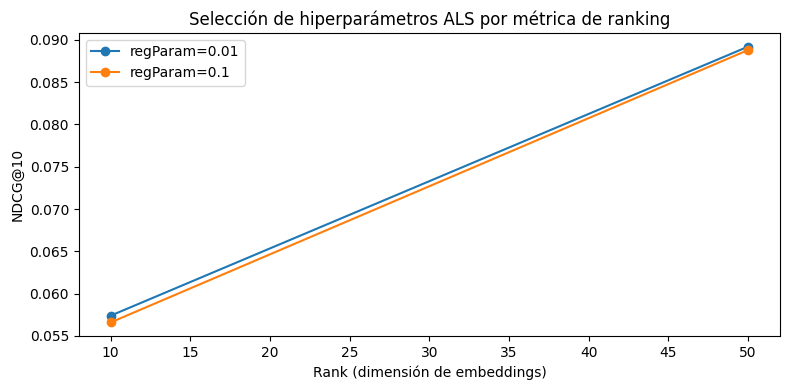

In [20]:
# 5.3 Tabla y visualización comparativa de hiperparámetros
results_pdf = pd.DataFrame([
    {
        "rank": r["rank"],
        "regParam": r["regParam"],
        "RMSE_referencia": r["rmse"],
        f"Precision@{K}": r[f"Precision@{K}"],
        f"Recall@{K}": r[f"Recall@{K}"],
        f"NDCG@{K}": r[f"NDCG@{K}"]
    }
    for r in results
]).sort_values(f"NDCG@{K}", ascending=False)

print(results_pdf.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
for reg in sorted(results_pdf["regParam"].unique()):
    subset = results_pdf[results_pdf["regParam"] == reg].sort_values("rank")
    ax.plot(subset["rank"], subset[f"NDCG@{K}"], marker="o", label=f"regParam={reg}")
ax.set_xlabel("Rank (dimensión de embeddings)")
ax.set_ylabel(f"NDCG@{K}")
ax.set_title("Selección de hiperparámetros ALS por métrica de ranking")
ax.legend()
plt.tight_layout()
plt.show()


26/06/19 00:12:52 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:12:52 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:12:58 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:13:02 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:13:03 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:13:07 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:13:07 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:13:08 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:13:08 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:13:10 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:13:10 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:13:12 WARN DAGScheduler: Broadcasting larg

  maxIter= 1 -> Precision@10=0.0031 | NDCG@10=0.0159


26/06/19 00:13:55 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:13:55 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:14:01 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:14:06 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:14:06 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:14:10 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:14:11 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:14:11 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:14:12 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:14:13 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:14:14 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:14:15 WARN DAGScheduler: Broadcasting larg

  maxIter= 2 -> Precision@10=0.0134 | NDCG@10=0.0757


26/06/19 00:15:06 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:15:06 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:15:12 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:15:18 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:15:19 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:15:27 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:15:28 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:15:29 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:15:30 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:15:33 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:15:33 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:15:36 WARN DAGScheduler: Broadcasting larg

...

  maxIter= 8 -> Precision@10=0.0157 | NDCG@10=0.0895


26/06/19 00:23:55 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:23:55 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:24:01 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:24:06 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:24:06 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:24:10 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:24:11 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:24:11 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:24:12 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:24:14 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:24:14 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:24:16 WARN DAGScheduler: Broadcasting larg

  maxIter= 9 -> Precision@10=0.0157 | NDCG@10=0.0895


26/06/19 00:25:35 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:25:35 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:25:40 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:25:45 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:25:46 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:25:50 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:25:50 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:25:51 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:25:51 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:25:53 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:25:53 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/06/19 00:25:55 WARN DAGScheduler: Broadcasting larg

  maxIter=10 -> Precision@10=0.0156 | NDCG@10=0.0892


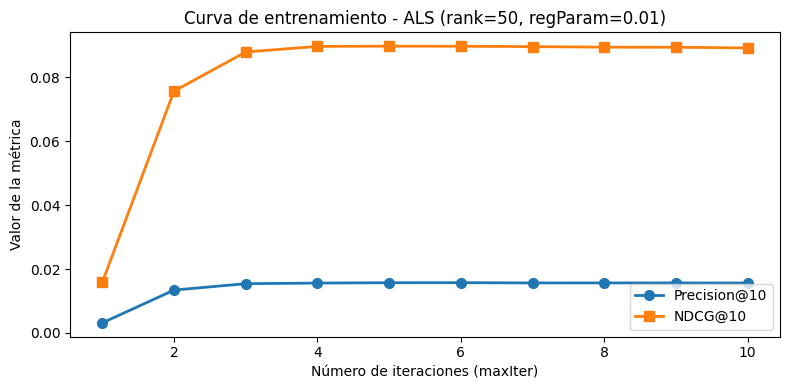

Mejor NDCG@10: 0.0898 (iteración 5)


In [21]:
# 5.4 Curva de entrenamiento — Precision@K por iteración
# Se usa la misma evaluación corregida: se filtran artistas vistos en train.

K_CURVE = 10
max_iters_range = list(range(1, 11))
precision_per_iter = []
ndcg_per_iter = []

for n_iter in max_iters_range:
    als_iter = ALS(
        maxIter=n_iter,
        rank=best['rank'],
        regParam=best['regParam'],
        userCol='user_index',
        itemCol='artist_index',
        ratingCol='rating',
        coldStartStrategy='drop',
        implicitPrefs=True,
        seed=42
    )
    m_iter = als_iter.fit(train_df)
    eval_iter = build_als_eval_df(m_iter, k=K_CURVE, k_candidates=K_CANDIDATES)
    ranking_iter = evaluate_ranking(eval_iter, k=K_CURVE)
    precision_per_iter.append(ranking_iter[f'Precision@{K_CURVE}'])
    ndcg_per_iter.append(ranking_iter[f'NDCG@{K_CURVE}'])
    print(
        f'  maxIter={n_iter:2d} -> '
        f'Precision@{K_CURVE}={ranking_iter[f"Precision@{K_CURVE}"]:.4f} | '
        f'NDCG@{K_CURVE}={ranking_iter[f"NDCG@{K_CURVE}"]:.4f}'
    )

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(max_iters_range, precision_per_iter, marker='o', linewidth=2, markersize=7, label=f'Precision@{K_CURVE}')
ax.plot(max_iters_range, ndcg_per_iter, marker='s', linewidth=2, markersize=7, label=f'NDCG@{K_CURVE}')
ax.set_xlabel('Número de iteraciones (maxIter)')
ax.set_ylabel('Valor de la métrica')
ax.set_title(f"Curva de entrenamiento - ALS (rank={best['rank']}, regParam={best['regParam']})")
ax.legend()
plt.tight_layout()
plt.show()

best_ndcg = max(ndcg_per_iter)
print(f'Mejor NDCG@{K_CURVE}: {best_ndcg:.4f} (iteración {ndcg_per_iter.index(best_ndcg)+1})')


## 6. Evaluación — Precision@K, Recall@K, NDCG@K

RMSE mide el error de predicción sobre play counts individuales, pero para un sistema de recomendación lo que importa es si los artistas relevantes aparecen en el top-K. Por eso calculamos métricas de ranking sobre el conjunto de test.

In [22]:
# 6.1 Generación de recomendaciones top-K
# Generamos más de K candidatos y luego excluimos artistas ya vistos en train.
# Esto evita evaluar un sistema que simplemente repite historial.

K = 10
K_CANDIDATES = 100

eval_df = build_als_eval_df(best_model, k=K, k_candidates=K_CANDIDATES).cache()
user_recs_filtered = eval_df.select("user_index", "rec_artists")

print(f"Usuarios para evaluar: {eval_df.count():,}")
print("Evaluación corregida: recomendaciones filtradas para excluir artistas vistos en train.")


26/06/19 00:27:16 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
26/06/19 00:27:48 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
26/06/19 00:27:54 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/06/19 00:28:12 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


Usuarios para evaluar: 22,100
Evaluación corregida: recomendaciones filtradas para excluir artistas vistos en train.


In [23]:
# 6.2 Métricas @K
# Las métricas se calculan sobre recomendaciones nuevas para el usuario.

ranking_final = evaluate_ranking(eval_df, k=K)
metrics_df = ranking_final["metrics_df"]

summary = pd.DataFrame([{
    f"Precision@{K}": ranking_final[f"Precision@{K}"],
    f"Recall@{K}": ranking_final[f"Recall@{K}"],
    f"NDCG@{K}": ranking_final[f"NDCG@{K}"]
}])

print(f"Métricas de evaluación corregidas (K={K}, filtrando artistas vistos en train):")
print(summary.round(4).to_string(index=False))

als_p10 = float(summary[f'Precision@{K}'].iloc[0])
als_r10 = float(summary[f'Recall@{K}'].iloc[0])
als_n10 = float(summary[f'NDCG@{K}'].iloc[0])


26/06/19 00:28:26 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


Métricas de evaluación corregidas (K=10, filtrando artistas vistos en train):
 Precision@10  Recall@10  NDCG@10
       0.0156     0.1562   0.0892


In [24]:
# 6.3 Recomendaciones concretas para 3 usuarios
# Mostramos historial de train, positivos de test y recomendaciones nuevas.
# Esto permite discutir si el modelo recomienda algo razonable y no solo repite artistas ya vistos.

user_index_map = interactions_indexed \
    .select("userID", "user_index").distinct() \
    .toPandas().set_index("user_index")["userID"].to_dict()

artist_index_map = interactions_indexed \
    .select("artistID", "artist_index").distinct() \
    .toPandas().set_index("artist_index")["artistID"].to_dict()

artist_names = interactions_raw.select("artistID", "artist_name").distinct().toPandas()
artist_names["artistID"] = artist_names["artistID"].astype(str)
id_to_name = dict(zip(artist_names["artistID"], artist_names["artist_name"]))

def artist_indices_to_names(indices):
    ids = [str(artist_index_map.get(i, i)) for i in indices]
    return [id_to_name.get(aid, f"ID:{aid}") for aid in ids]

sample_users = eval_df.filter(F.size("rec_artists") > 0).select("user_index").limit(3).toPandas()["user_index"].tolist()

for u_idx in sample_users:
    uid = user_index_map.get(u_idx, u_idx)
    print(f"\n{'='*70}")
    print(f"Usuario ID: {uid} (índice {u_idx})")

    history = train_df \
        .filter(F.col("user_index") == u_idx) \
        .orderBy(F.col("rating").desc()) \
        .limit(5) \
        .select("artistID", "rating").toPandas()
    history["artist_name"] = history["artistID"].astype(str).map(id_to_name)
    print("\nTop 5 más escuchados en TRAIN:")
    print(history[["artist_name", "rating"]].to_string(index=False))

    actual_row = eval_df.filter(F.col("user_index") == u_idx).select("actual_artists", "rec_artists", "train_artists").collect()[0]
    actual_names = artist_indices_to_names(actual_row["actual_artists"][:5])
    rec_names = artist_indices_to_names(actual_row["rec_artists"])

    print("\nArtistas relevantes en TEST (muestra):")
    for name in actual_names:
        print(f"  - {name}")

    print(f"\nTop {K} recomendaciones nuevas del modelo:")
    for i, name in enumerate(rec_names, 1):
        print(f"  {i:2d}. {name}")

    train_overlap = len(set(actual_row["rec_artists"]) & set(actual_row["train_artists"]))
    test_hits = len(set(actual_row["rec_artists"]) & set(actual_row["actual_artists"]))
    print("\nInterpretación:")
    print(f"  - Overlap con TRAIN: {train_overlap}") # (debería ser 0 por el filtro de vistos)
    print(f"  - Hits contra TEST: {test_hits}/{len(actual_row['actual_artists'])} positivos retenidos.")
   # Si predominan artistas muy populares, el modelo está capturando señal colaborativa, pero puede tener sesgo de popularidad


26/06/19 00:29:20 WARN DAGScheduler: Broadcasting large task binary with size 1410.9 KiB
26/06/19 00:29:22 WARN DAGScheduler: Broadcasting large task binary with size 1402.6 KiB
26/06/19 00:30:09 WARN DAGScheduler: Broadcasting large task binary with size 1752.4 KiB
26/06/19 00:30:21 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB



Usuario ID: a20178ee6cc9cf348f5d3251ba4908220a2580ac (índice 148)


26/06/19 00:30:21 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB



Top 5 más escuchados en TRAIN:
       artist_name  rating
   unknown artiist    23.0
       vienna teng    22.0
  fito y fitipaldi    20.0
       extremoduro    12.0
goldenthal, elliot    12.0


26/06/19 00:30:27 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


...


Artistas relevantes en TEST (muestra):
  - आशा भोंसले

Top 10 recomendaciones nuevas del modelo:
   1. artiste divers
   2. michael jacksons
   3. pink floyd
   4. unknown artiist
   5. nusrat fateh ali khan
   6. jim morrison - the doors
   7. ‌linkin park
   8. eminem
   9. sting
  10. bob marley

Interpretación:
  - Overlap con TRAIN: 0
  - Hits contra TEST: 0/1 positivos retenidos.

Usuario ID: 30d285b461d5f561d943b47900065dde1345fc15 (índice 471)


26/06/19 00:30:43 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB



Top 5 más escuchados en TRAIN:
    artist_name  rating
julieta venégas    37.0
        pastora    15.0
    russian red    12.0
    a. c. jobim     9.0
 joaquķn sabina     9.0


26/06/19 00:30:48 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB



Artistas relevantes en TEST (muestra):
  - maria bethania

Top 10 recomendaciones nuevas del modelo:
   1. shawnna & ludacris
   2. エイミー・ワインハウス
   3. gilberto astrud
   4. adriana calacanhoto
   5. joão gilberto
   6. costa, gal
   7. la oreja de van gogh
   8. gilberto gil
   9. u2
  10. artiste divers

Interpretación:
  - Overlap con TRAIN: 0
  - Hits contra TEST: 0/1 positivos retenidos.


## 6.4 Visualización de embeddings con PCA

ALS aprende un vector latente por artista. Proyectamos con PCA a 2D para ver qué estructura capturó el modelo: artistas escuchados en contextos similares deberían quedar cerca en el espacio de embeddings.

26/06/19 00:30:56 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
26/06/19 00:31:39 WARN DAGScheduler: Broadcasting large task binary with size 1752.4 KiB


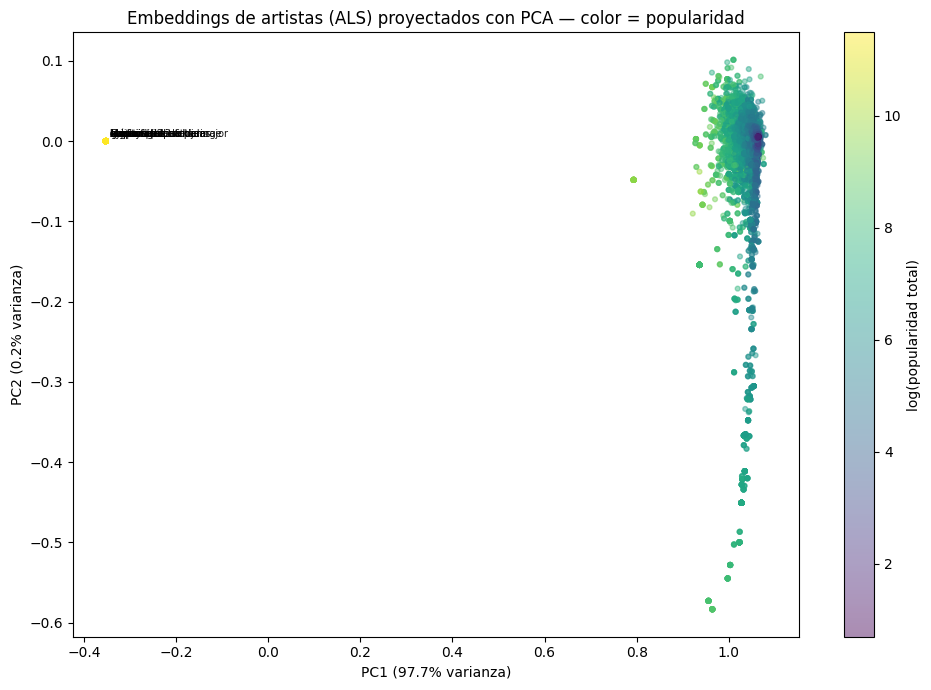

Varianza explicada por PC1+PC2: 97.8%


In [25]:
# 6.4 PCA de embeddings de artistas (ALS itemFactors)
# ALS produce best_model.itemFactors: vector latente por artista.
# Proyectamos con PCA a 2D y coloreamos por popularidad.
# Si el modelo capturó señal real, artistas populares deberían separarse
# de los de nicho, y artistas similares deberían agruparse.

from sklearn.decomposition import PCA
import numpy as np

# Extraer embeddings y construir tabla con metadata
item_factors_pd = best_model.itemFactors.toPandas().rename(columns={'id': 'artist_index'})

artist_idx_pd = (
    interactions_indexed.select('artist_index', 'artistID').distinct().toPandas()
)
# artistID son MBIDs (strings UUID) en el dataset 360K — no integers
artist_idx_pd['artistID'] = artist_idx_pd['artistID'].astype(str).str.strip()

artist_feat_pd = artist_features.toPandas()
artist_feat_pd['artistID'] = artist_feat_pd['artistID'].astype(str).str.strip()

artist_names_pd = interactions_raw.select("artistID", "artist_name").distinct().toPandas()
artist_names_pd["artistID"] = artist_names_pd["artistID"].astype(str).str.strip()

emb_df = (
    item_factors_pd
    .merge(artist_idx_pd, on='artist_index', how='left')
    .merge(artist_feat_pd[['artistID', 'log_artist_popularity', 'n_unique_listeners']], on='artistID', how='left')
    .merge(artist_names_pd, on='artistID', how='left')
    .dropna(subset=['log_artist_popularity'])
)

# PCA 2D sobre la matriz de embeddings
X = np.vstack(emb_df['features'].values)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
emb_df = emb_df.copy()
emb_df['pc1'] = coords[:, 0]
emb_df['pc2'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    emb_df['pc1'], emb_df['pc2'],
    c=emb_df['log_artist_popularity'],
    cmap='viridis', alpha=0.45, s=12
)
plt.colorbar(sc, ax=ax, label='log(popularidad total)')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.set_title('Embeddings de artistas (ALS) proyectados con PCA — color = popularidad')

# Etiquetar top 15 artistas más populares
# columna renombrada: 'name' → 'artist_name' en dataset 360K
for _, row in emb_df.nlargest(15, 'log_artist_popularity').iterrows():
    ax.annotate(row['artist_name'], (row['pc1'], row['pc2']),
                fontsize=7, alpha=0.9,
                xytext=(3, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

var_total = sum(pca.explained_variance_ratio_[:2]) * 100
print(f'Varianza explicada por PC1+PC2: {var_total:.1f}%')

# artistas cercanos en el espacio PCA tienen patrones de escucha similares
# entre los usuarios --> el modelo aprende estructura latente sin usar features
#explicitas de genero o estilo musical


## 7. Limitaciones de ALS y cómo resolverlas

ALS factoriza la matriz usuario-artista en embeddings latentes pero **no incorpora features adicionales** directamente. Las features calculadas en el punto 4 (log_total_plays, n_unique_artists, log_artist_popularity, n_distinct_tags) no entran al modelo — solo se usan en el análisis.

**Cómo se resolvería en un sistema real:**
- **Modelo híbrido:** usar los embeddings de ALS como features de entrada para un segundo modelo (gradient boosting o MLP) que sí pueda combinarlos con features adicionales
- **Two-Tower:** reemplazar ALS por una arquitectura que combina embedding de ID con features en cada torre — requiere GPU para ser práctico
- **LightFM:** extiende MF con features de usuario e ítem de forma nativa

## 8. Escalabilidad

Esta sección describe qué cambiaría en el pipeline con un cluster Databricks de 4 workers con GPU, 100 millones de interacciones y actualización de recomendaciones cada 24 horas.

### Negative sampling a escala
ALS con `implicitPrefs=True` no requiere negative sampling explícito — trata todas las interacciones no observadas como negativos implícitos con peso bajo. A 100M de interacciones esto sigue funcionando porque ALS distribuye el cómputo en bloques sobre el cluster. Si se migrara a BPR o Two-Tower, el negative sampling explícito con crossJoin sería inviable: la alternativa es **reservoir sampling por partición**, generando negativos dentro de cada shard sin shuffles globales.

### Por qué toPandas() deja de funcionar
Con 100M de interacciones, `toPandas()` intenta traer todo al driver. Incluso con 64GB de RAM en el driver, una matriz de esa escala lo agota. El reemplazo es Parquet particionado en DBFS/S3 para persistencia y `display()` de Databricks para visualización — que muestran solo una muestra al driver. Para plots, se agregan los datos en Spark y solo el resultado (miles de filas) se convierte a pandas.

### TorchDistributor
ALS es nativo en Spark y escala sin TorchDistributor. Para modelos PyTorch (BPR, Two-Tower), `TorchDistributor` de Databricks lanza el training loop con `DistributedDataParallel` en todos los workers. Cada worker procesa un shard del dataset y los gradientes se sincronizan en cada step. Los embeddings de usuarios e ítems deben sincronizarse explícitamente entre workers para evitar inconsistencias.

### Serving en tiempo real
Las recomendaciones pre-calculadas cada 24h con ALS se escriben en **Delta Lake** indexado por user_id. Una API REST lee de Delta Lake con latencia de milisegundos. Para cold start (usuarios nuevos sin historial), se sirve una lista de top artistas por popularidad global hasta que el usuario acumula suficientes interacciones para el próximo ciclo de reentrenamiento.

### Nota adicional sobre serving y evaluación a escala

En producción, además de las métricas @K calculadas offline, se deberían monitorear cobertura del catálogo, diversidad, tasa de recomendación de long tail y métricas online como CTR o conversión. Esto es importante porque un recomendador puede obtener buena Precision@K recomendando artistas populares, pero aportar poco descubrimiento real.


---
## 10. Comparacion: BPR vs ALS

**BPR (Bayesian Personalized Ranking)** aprende a *ordenar* en lugar de predecir ratings: entrena con tripletas (usuario, item positivo, item negativo) y optimiza que el score del positivo supere al del negativo. Su funcion de perdida es `-log(sigmoid(score_pos - score_neg))`, una aproximacion diferenciable al AUC.

Usamos el mismo subconjunto y el mismo split train/test que ALS para comparacion justa. BPR corre en PyTorch (CPU); el preprocesamiento (ya hecho) es identico al de ALS.

In [26]:
# 10.1 Preparación de datos y definición del modelo BPR
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random

# BPR es un experimento extra comparativo. El preprocesamiento principal sigue estando en Spark.
# Pasamos a pandas solo el subconjunto ya procesado para entrenar un modelo PyTorch simple en Colab.
train_pd_bpr = train_df.select('user_index', 'artist_index').toPandas()
test_pd_bpr  = test_df.select('user_index',  'artist_index').toPandas()

n_users_bpr = int(interactions_indexed.agg(F.max('user_index')).collect()[0][0]) + 1
n_items_bpr = int(interactions_indexed.agg(F.max('artist_index')).collect()[0][0]) + 1
print(f'Embedding: {n_users_bpr} usuarios x {n_items_bpr} artistas')
print(f'Train BPR: {len(train_pd_bpr):,} pares usuario-artista')

class BPRDataset(Dataset):
    # Genera tripletas (usuario, item_pos, item_neg) para BPR.
    # Negative sampling: uniforme sobre items no vistos en train por el usuario.
    # Evita crossJoin usuario x item, que sería inviable a escala.
    def __init__(self, df, n_items):
        self.user_items = df.groupby('user_index')['artist_index'].apply(set).to_dict()
        self.n_items = int(n_items)
        self.users = df['user_index'].values.astype('int64')
        self.pos_items = df['artist_index'].values.astype('int64')

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u, pos = int(self.users[idx]), int(self.pos_items[idx])
        seen = self.user_items.get(u, set())
        neg = random.randrange(self.n_items)
        while neg in seen:
            neg = random.randrange(self.n_items)
        return (torch.tensor(u, dtype=torch.long),
                torch.tensor(pos, dtype=torch.long),
                torch.tensor(neg, dtype=torch.long))

class BPRModel(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=32):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

    def score(self, user, item):
        return (self.user_emb(user) * self.item_emb(item)).sum(dim=1)

    def forward(self, user, pos, neg):
        diff = self.score(user, pos) - self.score(user, neg)
        return -torch.log(torch.sigmoid(diff) + 1e-8).mean()

print('Clases BPRDataset y BPRModel definidas.')


26/06/19 00:32:47 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/06/19 00:32:56 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/06/19 00:33:43 WARN DAGScheduler: Broadcasting large task binary with size 1404.5 KiB
26/06/19 00:34:27 WARN DAGScheduler: Broadcasting large task binary with size 1736.0 KiB


Embedding: 22125 usuarios x 25128 artistas
Train BPR: 787,440 pares usuario-artista
Clases BPRDataset y BPRModel definidas.


  Epoch   5/25 — BPR Loss: 0.0701
  Epoch  10/25 — BPR Loss: 0.0598
  Epoch  15/25 — BPR Loss: 0.0594
  Epoch  20/25 — BPR Loss: 0.0601
  Epoch  25/25 — BPR Loss: 0.0606


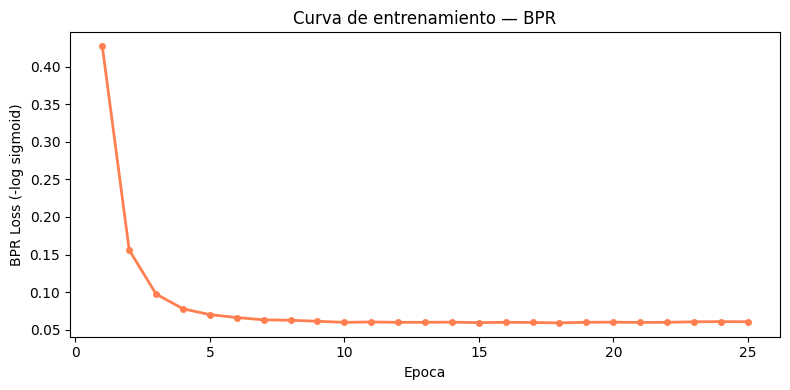

Loss final: 0.0606


In [27]:
# 10.2 Entrenamiento BPR con curva de perdida
EMB_DIM    = 32
EPOCHS_BPR = 25
LR_BPR     = 0.01
BATCH_BPR  = 1024

torch.manual_seed(42)
model_bpr = BPRModel(n_users_bpr, n_items_bpr, emb_dim=EMB_DIM)
optimizer_bpr = torch.optim.Adam(model_bpr.parameters(), lr=LR_BPR)

dataset_bpr = BPRDataset(train_pd_bpr, n_items=n_items_bpr)
loader_bpr  = DataLoader(dataset_bpr, batch_size=BATCH_BPR, shuffle=True)

losses_bpr = []
for epoch in range(1, EPOCHS_BPR + 1):
    model_bpr.train()
    epoch_loss = 0.0
    for u, pos, neg in loader_bpr:
        optimizer_bpr.zero_grad()
        loss = model_bpr(u, pos, neg)
        loss.backward()
        optimizer_bpr.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(loader_bpr)
    losses_bpr.append(avg)
    if epoch % 5 == 0:
        print(f'  Epoch {epoch:3d}/{EPOCHS_BPR} — BPR Loss: {avg:.4f}')

# Curva de perdida
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS_BPR + 1), losses_bpr, color='coral', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Epoca')
ax.set_ylabel('BPR Loss (-log sigmoid)')
ax.set_title('Curva de entrenamiento — BPR')
plt.tight_layout()
plt.show()
print(f'Loss final: {losses_bpr[-1]:.4f}')


Comparación ALS vs BPR con evaluación corregida (K=10, sin items vistos en train):

                      Modelo  Precision@10  Recall@10  NDCG@10
ALS (rank=50, regParam=0.01)        0.0156     0.1562   0.0892
 BPR (emb_dim=32, epochs=25)        0.0092     0.0917   0.0524


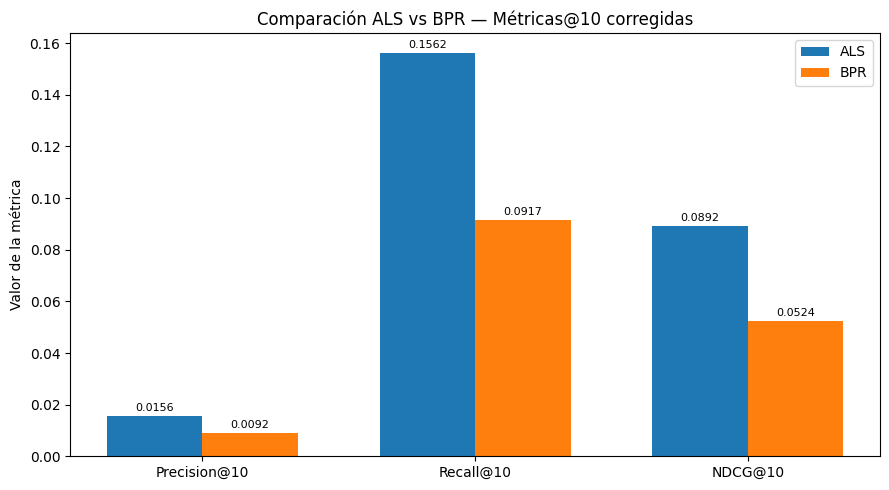


Modelo con mayor NDCG@10: ALS


In [28]:
# 10.3 Evaluación BPR y comparación con ALS
# Misma lógica conceptual que ALS: top-K filtrando items vistos en train.
K_BPR = 10
model_bpr.eval()

test_positives = test_pd_bpr.groupby('user_index')['artist_index'].apply(set).to_dict()
train_seen_bpr = train_pd_bpr.groupby('user_index')['artist_index'].apply(set).to_dict()

precisions_bpr, recalls_bpr, ndcgs_bpr = [], [], []

with torch.no_grad():
    for user_idx, actual in test_positives.items():
        if user_idx >= n_users_bpr:
            continue
        seen = train_seen_bpr.get(user_idx, set())
        u_vec = model_bpr.user_emb(torch.tensor([int(user_idx)]))
        scores_bpr = (u_vec * model_bpr.item_emb.weight).sum(dim=1).numpy()
        ranked_items = scores_bpr.argsort()[::-1].tolist()
        top_k = []
        for item in ranked_items:
            if item not in seen:
                top_k.append(item)
            if len(top_k) == K_BPR:
                break
        hits = [1 if item in actual else 0 for item in top_k]
        p = sum(hits) / len(top_k) if top_k else 0.0
        r = sum(hits) / len(actual) if actual else 0.0
        dcg = sum(h / np.log2(i + 2) for i, h in enumerate(hits))
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), len(top_k))))
        ndcg = dcg / idcg if idcg > 0 else 0.0
        precisions_bpr.append(p)
        recalls_bpr.append(r)
        ndcgs_bpr.append(ndcg)

bpr_p10 = float(np.mean(precisions_bpr))
bpr_r10 = float(np.mean(recalls_bpr))
bpr_n10 = float(np.mean(ndcgs_bpr))

comparison = pd.DataFrame({
    'Modelo': [f"ALS (rank={best['rank']}, regParam={best['regParam']})", f'BPR (emb_dim={EMB_DIM}, epochs={EPOCHS_BPR})'],
    'Precision@10': [round(als_p10, 4), round(bpr_p10, 4)],
    'Recall@10': [round(als_r10, 4), round(bpr_r10, 4)],
    'NDCG@10': [round(als_n10, 4), round(bpr_n10, 4)],
})
print('Comparación ALS vs BPR con evaluación corregida (K=10, sin items vistos en train):\n')
print(comparison.to_string(index=False))

metrics_cols = ['Precision@10', 'Recall@10', 'NDCG@10']
x = np.arange(len(metrics_cols))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, comparison[comparison['Modelo'].str.startswith('ALS')][metrics_cols].values[0], width, label='ALS')
bars2 = ax.bar(x + width/2, comparison[comparison['Modelo'].str.startswith('BPR')][metrics_cols].values[0], width, label='BPR')
ax.set_xticks(x)
ax.set_xticklabels(metrics_cols)
ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación ALS vs BPR — Métricas@10 corregidas')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

winner = 'ALS' if als_n10 >= bpr_n10 else 'BPR'
print(f'\nModelo con mayor NDCG@10: {winner}')
# BPR optimiza ranking por pares positivo/negativo; ALS implícito factoriza la matriz usuario-artista
# La comparación es orientativa porque BPR usa PyTorch local y ALS corre distribuido en Spark


---
## 9. Bonus opcional: Recomendaciones personalizadas con datos reales de Last.fm

Esta sección queda protegida con `RUN_LASTFM_BONUS = False` para que el notebook pueda ejecutarse de punta a punta sin pedir credenciales. Para usarla, cambiar el flag a `True` y cargar una API key de Last.fm.


In [35]:
# 9.1 Configuración opcional de credenciales 
# Para ejecutar el bonus, cambiar "RUN_LASTFM_BONUS" a True y cargar una API key de Last.fm.

RUN_LASTFM_BONUS = True
LASTFM_USER = "LaraPasca"  # usuario de Last.fm para el bonus opcional

if RUN_LASTFM_BONUS:
    import os
    import requests
    from getpass import getpass
    os.environ["LASTFM_API_KEY"] = getpass("Last.fm API key: ")
    API_KEY = os.environ["LASTFM_API_KEY"]
    BASE_URL = "http://ws.audioscrobbler.com/2.0/"
    print(f"Usuario: {LASTFM_USER}")
    print("API key: configurada ✓")
else:
    print("Bonus Last.fm omitido. Para ejecutarlo, setear RUN_LASTFM_BONUS = True.")


Last.fm API key:  ········


Usuario: LaraPasca
API key: configurada ✓


In [36]:
if RUN_LASTFM_BONUS:
    # 9.2 Descarga del historial real desde la API de Last.fm 
    # Usamos user.getTopArtists para obtener los artistas más escuchados
    # con su play count real — el mismo formato que user_artists.dat

    def get_top_artists(user, api_key, limit=200):
        """Obtiene los top artistas de un usuario con sus play counts."""
        params = {
            "method": "user.getTopArtists",
            "user": user,
            "api_key": api_key,
            "format": "json",
            "limit": limit,
            "period": "overall"  # historial completo
        }
        r = requests.get(BASE_URL, params=params)
        r.raise_for_status()
        artists = r.json()["topartists"]["artist"]
        return [
            {"name": a["name"], "playcount": int(a["playcount"])}
            for a in artists
        ]

    top_artists = get_top_artists(LASTFM_USER, API_KEY, limit=200)

    print(f"Artistas obtenidos: {len(top_artists)}")
    print(f"\nTus 10 artistas más escuchados en Last.fm:")
    for i, a in enumerate(top_artists[:10], 1):
        print(f"  {i:2d}. {a['name']} ({a['playcount']:,} plays)")
else:
    print('Sección bonus omitida: RUN_LASTFM_BONUS = False')


Artistas obtenidos: 200

Tus 10 artistas más escuchados en Last.fm:
   1. Taylor Swift (10,121 plays)
   2. One Direction (7,665 plays)
   3. Morat (6,932 plays)
   4. Noah Kahan (4,784 plays)
   5. Glee Cast (3,745 plays)
   6. Reneé Rapp (2,694 plays)
   7. Lizzy McAlpine (1,860 plays)
   8. Zoe Gotusso (1,773 plays)
   9. Gracie Abrams (1,534 plays)
  10. Crazy Ex-Girlfriend Cast (1,510 plays)


In [37]:
if RUN_LASTFM_BONUS:
    # 9.3 Cruce con el dataset: ¿qué artistas tuyos están en el modelo?
    # El modelo solo conoce artistas que aparecen en el dataset 360K
    # Hacemos un cruce por nombre (lowercase, sin espacios extra) para matchear

    import pandas as pd

    # Nombres del dataset normalizados
    # En el dataset 360K los nombres están en interactions_raw como artist_name
    dataset_artists = interactions_raw.select("artistID", "artist_name").distinct().toPandas()
    dataset_artists["name_norm"] = dataset_artists["artist_name"].str.lower().str.strip()
    dataset_name_to_id = dict(zip(dataset_artists["name_norm"], dataset_artists["artistID"].astype(str)))

    # Cruce con tu historial
    my_artists_matched = []
    my_artists_missing = []

    for a in top_artists:
        norm = a["name"].lower().strip()
        if norm in dataset_name_to_id:
            my_artists_matched.append({
                "name": a["name"],
                "playcount": a["playcount"],
                "artistID": dataset_name_to_id[norm]
            })
        else:
            my_artists_missing.append(a["name"])

    print(f"Tus artistas que SÍ están en el dataset: {len(my_artists_matched)}")
    print(f"Tus artistas que NO están en el dataset: {len(my_artists_missing)}")
    print(f"\nEjemplos de artistas tuyos fuera del dataset (demasiado nuevos o nicho):")
    for name in my_artists_missing[:8]:
        print(f"  - {name}")
else:
    print('Sección bonus omitida: RUN_LASTFM_BONUS = False')


Tus artistas que SÍ están en el dataset: 83
Tus artistas que NO están en el dataset: 117

Ejemplos de artistas tuyos fuera del dataset (demasiado nuevos o nicho):
  - One Direction
  - Morat
  - Noah Kahan
  - Reneé Rapp
  - Lizzy McAlpine
  - Zoe Gotusso
  - Gracie Abrams
  - Crazy Ex-Girlfriend Cast


In [38]:
if RUN_LASTFM_BONUS:
    # 9.4 Reentrenamiento incluyendo al usuario real
    # Problema: ALS aprende un vector latente por usuario durante el entrenamiento.
    # Un usuario nuevo (cold start) no tiene vector → no puede recibir recomendaciones.
    # Solución: agregamos las interacciones del usuario real al dataset y reentrenamos.
    #
    # En producción esto se haría con reentrenamiento incremental o aproximaciones
    # como promediar embeddings de usuarios similares. Acá reentrenamos completo
    # porque el dataset es pequeño y queremos mostrar el concepto.

    MY_USER_ID = "99999_lara"  # ID ficticio string — compatible con userID SHA1 del dataset 360K

    # Creamos DataFrame de Spark con las interacciones del usuario real
    # artistID son MBIDs (strings) en el dataset 360K — no integers
    my_interactions_pd = pd.DataFrame([
        {"userID": MY_USER_ID, "artistID": a["artistID"], "weight": a["playcount"]}
        for a in my_artists_matched
    ])

    if len(my_interactions_pd) == 0:
        print("No se encontraron artistas tuyos en el dataset. Probá con más artistas o ajustá el matching.")
    else:
        my_interactions_spark = spark.createDataFrame(my_interactions_pd)

        # Unimos con el dataset original (antes del filtrado de subconjunto)
        # Usamos interactions_raw completo para que el usuario tenga más contexto
        combined = interactions_raw.select("userID", "artistID", "weight").union(
            my_interactions_spark.select("userID", "artistID", "weight")
        )

        # Re-indexamos con StringIndexer sobre el dataset combinado
        from pyspark.ml.feature import StringIndexer
        from pyspark.sql.types import IntegerType, FloatType

        user_idx2 = StringIndexer(inputCol="userID", outputCol="user_index").fit(combined)
        artist_idx2 = StringIndexer(inputCol="artistID", outputCol="artist_index").fit(combined)

        combined_indexed = user_idx2.transform(combined)
        combined_indexed = artist_idx2.transform(combined_indexed)
        combined_indexed = combined_indexed \
            .withColumn("user_index", F.col("user_index").cast(IntegerType())) \
            .withColumn("artist_index", F.col("artist_index").cast(IntegerType())) \
            .withColumn("rating", F.col("weight").cast(FloatType()))

        combined_indexed.cache()

        # Reentrenamos ALS con la mejor configuración encontrada antes
        als_personal = ALS(
            maxIter=10,
            rank=best["rank"],
            regParam=best["regParam"],
            userCol="user_index",
            itemCol="artist_index",
            ratingCol="rating",
            coldStartStrategy="drop",
            implicitPrefs=True
        )
        model_personal = als_personal.fit(combined_indexed)
        print(f"Modelo reentrenado con {combined_indexed.count():,} interacciones totales")
        print(f"(dataset original + {len(my_interactions_pd)} interacciones tuyas)")
else:
    print('Sección bonus omitida: RUN_LASTFM_BONUS = False')


26/06/19 00:46:26 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 00:46:33 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 00:47:12 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 00:47:19 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 00:47:29 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 00:47:36 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 00:47:48 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 00:47:52 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 00:47:58 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 00:48:22 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 00:48:26 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 00:49:02 WARN DAGScheduler: Broadc

[4239.578s][warning][gc,alloc] Executor task launch worker for task 3.0 in stage 14159.0 (TID 25124): Retried waiting for GCLocker too often allocating 107138 words


26/06/19 00:52:45 WARN DAGScheduler: Broadcasting large task binary with size 29.7 MiB
26/06/19 00:52:49 WARN DAGScheduler: Broadcasting large task binary with size 29.7 MiB


[4277.622s][warning][gc,alloc] Executor task launch worker for task 7.0 in stage 14173.0 (TID 25148): Retried waiting for GCLocker too often allocating 131072 words


26/06/19 00:53:16 WARN DAGScheduler: Broadcasting large task binary with size 29.7 MiB
26/06/19 00:53:22 WARN DAGScheduler: Broadcasting large task binary with size 29.7 MiB
26/06/19 00:53:47 WARN DAGScheduler: Broadcasting large task binary with size 29.7 MiB
26/06/19 00:53:51 WARN DAGScheduler: Broadcasting large task binary with size 29.8 MiB
26/06/19 00:54:17 WARN DAGScheduler: Broadcasting large task binary with size 29.8 MiB
26/06/19 00:54:23 WARN DAGScheduler: Broadcasting large task binary with size 29.8 MiB
26/06/19 00:54:47 WARN DAGScheduler: Broadcasting large task binary with size 29.8 MiB
26/06/19 00:54:50 WARN DAGScheduler: Broadcasting large task binary with size 29.8 MiB
26/06/19 00:55:18 WARN DAGScheduler: Broadcasting large task binary with size 29.8 MiB
26/06/19 00:55:25 WARN DAGScheduler: Broadcasting large task binary with size 29.8 MiB
26/06/19 00:55:48 WARN DAGScheduler: Broadcasting large task binary with size 29.8 MiB
26/06/19 00:55:52 WARN DAGScheduler: Broadc

Modelo reentrenado con 17,559,613 interacciones totales
(dataset original + 83 interacciones tuyas)


In [41]:
if RUN_LASTFM_BONUS:
    # 9.5 Recomendaciones personalizadas
    # Generamos recomendaciones para el usuario real en 4 categorías:
    #   1. Top 5 artistas recomendados (que no escuchaste)
    #   2. Top 5 artistas recomendados que escuchaste MUY poco (redescubrimientos)
    #   3. Top 5 canciones populares de los artistas recomendados (via API)
    #   4. Top 5 canciones de artistas que escuchaste poco (via API)

    # Índice del usuario real en el modelo reentrenado
    my_index = combined_indexed \
        .filter(F.col("userID") == MY_USER_ID) \
        .select("user_index").first()["user_index"]

    # Índices de artistas que ya escuché (para excluirlos)
    my_artist_ids = set(str(a["artistID"]) for a in my_artists_matched)
    my_low_plays = set(
        str(a["artistID"]) for a in my_artists_matched
        if a["playcount"] < 150  # escuchados muy poco
    )

    # Mapas de índice a ID y nombre para el modelo reentrenado
    artist_idx_map2 = combined_indexed \
        .select("artistID", "artist_index").distinct() \
        .toPandas().set_index("artist_index")["artistID"].apply(str).to_dict()

    # Top 50 recomendaciones para tener margen de filtrado
    my_user_df = spark.createDataFrame([(my_index,)], ["user_index"])
    my_recs_raw = model_personal.recommendForUserSubset(my_user_df, 50)
    my_recs_list = my_recs_raw.collect()[0]["recommendations"]

    # Separamos en: nunca escuchados vs escuchados muy poco
    never_heard = []
    rarely_heard = []

    for r in my_recs_list:
        aid = artist_idx_map2.get(r.artist_index, None)
        if aid is None:
            continue
        name = id_to_name.get(aid, f"ID:{aid}")
        if aid in my_low_plays:
            rarely_heard.append({"name": name, "score": r.rating, "artistID": aid})
        elif aid not in my_artist_ids:
            never_heard.append({"name": name, "score": r.rating, "artistID": aid})

    top_never = never_heard[:5]
    top_rarely = rarely_heard[:5]

    print("=" * 55)
    print(f"  Recomendaciones personalizadas para @{LASTFM_USER}")
    print("=" * 55)

    print("\n🎵 ARTISTAS QUE DEBERÍAS ESCUCHAR (nunca los escuchaste):")
    for i, a in enumerate(top_never, 1):
        print(f"  {i}. {a['name']}")

    print("\n🔁 REDESCUBRIMIENTOS (los escuchaste muy poco, el modelo cree que te van a gustar):")
    for i, a in enumerate(top_rarely, 1):
        plays = next((x["playcount"] for x in my_artists_matched if str(x["artistID"]) == a["artistID"]), 0)
        print(f"  {i}. {a['name']} (solo {plays} plays tuyos)")
else:
    print('Sección bonus omitida: RUN_LASTFM_BONUS = False')


26/06/19 01:08:06 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 01:08:07 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 01:08:09 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 01:08:12 WARN DAGScheduler: Broadcasting large task binary with size 29.6 MiB
26/06/19 01:08:24 WARN DAGScheduler: Broadcasting large task binary with size 29.9 MiB
26/06/19 01:08:29 WARN DAGScheduler: Broadcasting large task binary with size 29.9 MiB
26/06/19 01:12:57 WARN DAGScheduler: Broadcasting large task binary with size 29.9 MiB


  Recomendaciones personalizadas para @LaraPasca

🎵 ARTISTAS QUE DEBERÍAS ESCUCHAR (nunca los escuchaste):
  1. journey
  2. flight of the conchords
  3. michael jacksons
  4. artiste divers
  5. moulin rouge!

🔁 REDESCUBRIMIENTOS (los escuchaste muy poco, el modelo cree que te van a gustar):
  1. shakira (solo 135 plays tuyos)
  2. beatles, the (solo 142 plays tuyos)
  3. shawnna & ludacris (solo 887 plays tuyos)
  4. coldplay (solo 121 plays tuyos)


In [42]:
if RUN_LASTFM_BONUS:
    # 9.6 Canciones recomendadas via API de Last.fm
    # ALS recomienda artistas, no canciones. Para recomendar canciones
    # usamos la API de Last.fm para obtener los top tracks de cada artista recomendado.
    # Esto simula cómo un sistema real combina CF (collaborative filtering)
    # con metadata externa para dar recomendaciones más concretas.

    def get_top_tracks(artist_name, api_key, limit=1):
        """Obtiene los top tracks de un artista via API de Last.fm."""
        params = {
            "method": "artist.getTopTracks",
            "artist": artist_name,
            "api_key": api_key,
            "format": "json",
            "limit": limit
        }
        try:
            r = requests.get(BASE_URL, params=params, timeout=5)
            tracks = r.json().get("toptracks", {}).get("track", [])
            if isinstance(tracks, list) and tracks:
                return [t["name"] for t in tracks[:limit]]
            return []
        except:
            return []

    print("=" * 55)
    print(f"  Canciones recomendadas para @{LASTFM_USER}")
    print("=" * 55)

    print("\n🎶 CANCIONES DE ARTISTAS QUE NUNCA ESCUCHASTE:")
    for a in top_never:
        tracks = get_top_tracks(a["name"], API_KEY, limit=1)
        track_str = f" → '{tracks[0]}'" if tracks else ""
        print(f"  • {a['name']}{track_str}")

    print("\n🔀 CANCIONES DE TUS REDESCUBRIMIENTOS:")
    for a in top_rarely:
        tracks = get_top_tracks(a["name"], API_KEY, limit=1)
        track_str = f" → '{tracks[0]}'" if tracks else ""
        plays = next((x["playcount"] for x in my_artists_matched if str(x["artistID"]) == a["artistID"]), 0)
        print(f"  • {a['name']} ({plays} plays){track_str}")

    print("\n" + "=" * 55)
    print("  Nota: ALS recomienda artistas basándose en patrones")
    print("  de escucha colectivos. Las canciones son el top track")
    print("  de cada artista según Last.fm — un sistema completo")
    print("  usaría también historial de canciones individuales.")
    print("=" * 55)
else:
    print('Sección bonus omitida: RUN_LASTFM_BONUS = False')


  Canciones recomendadas para @LaraPasca

🎶 CANCIONES DE ARTISTAS QUE NUNCA ESCUCHASTE:
  • journey → 'Don't Stop Believin''
  • flight of the conchords → 'Business Time'
  • michael jacksons → 'Billie Jean'
  • artiste divers → 'Move Your Body (Funkanomics Remix)'
  • moulin rouge! → 'Come What May'

🔀 CANCIONES DE TUS REDESCUBRIMIENTOS:
  • shakira (135 plays) → 'Hips Don't Lie (feat. Wyclef Jean)'
  • beatles, the (142 plays) → 'Here Comes the Sun - Remastered 2009'
  • shawnna & ludacris (887 plays) → 'Shake That Sh** (Radio Edit)'
  • coldplay (121 plays) → 'Yellow'

  Nota: ALS recomienda artistas basándose en patrones
  de escucha colectivos. Las canciones son el top track
  de cada artista según Last.fm — un sistema completo
  usaría también historial de canciones individuales.
